# same but no VPR penalty at all -- 1 = model comp

In [ ]:
import numpy as np
import pandas as pd
import os
import scipy
from tqdm.notebook import tqdm
from scipy.optimize import minimize
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
input_dir = './indiv_dvals/'
slsqp = True

output_dir = os.path.join(os.getcwd(), 'vf_slsqp_noVPRpen')
solver_method = 'SLSQP'

os.makedirs(output_dir, exist_ok=True)
participants = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 32]

# --- Helper Functions ---

def get_monotonic_constraints(start_idx, length=5):
    cons = []
    for i in range(start_idx, start_idx + length - 1):
        cons.append({'type': 'ineq', 'fun': lambda p, i=i: p[i+1] - p[i]})
    return cons

def get_llh_unimodal(x_vec, data, snr_list, mu_min, mu_max, sigma_snr):
    llh = 0
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        subset = data[snr_list == snr]
        if len(subset) == 0: continue
        mu = mu_min + x_vec[i] * (mu_max - mu_min)
        llh += np.sum(scipy.stats.norm.logpdf(subset, loc=mu, scale=sigma_snr))
    return llh

def get_llh_bimodal(pars, data, snr_list, mu_min, sigma_low, sigma_high):
    x_vec, mu_h_vec = pars[:5], pars[5:10]
    llh = 0
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        subset = data[snr_list == snr]
        if len(subset) == 0: continue
        l_low = scipy.stats.norm.logpdf(subset, loc=mu_min, scale=sigma_low)
        l_high = scipy.stats.norm.logpdf(subset, loc=mu_h_vec[i], scale=sigma_high)
        llh += np.sum(scipy.special.logsumexp(
            np.vstack([l_low + np.log(1 - x_vec[i] + 1e-9),
                       l_high + np.log(x_vec[i] + 1e-9)]), axis=0))
    return llh

# --- Main Computation ---
bif_results, auc_results, trial_rows = [], [], []

for part in tqdm(participants):
    for task in ['active', 'passive']:
        if part == 22 or (task == 'passive' and part in [9, 29]): continue
        for roi_key in ['A1', 'NoA1']:
            key = f'subj_{part}_{task}_{roi_key}'
            fname = os.path.join(input_dir, f'{key}_thr10.csv')
            if not os.path.exists(fname): continue

            df = pd.read_csv(fname)
            dvals, snrs, chunks = df['dvals'].values, df['true_labels'].values, df['chunks'].values

            # 1. Bifurcation Score (CV)
            logo = LeaveOneGroupOut()
            cv_scores = {'null': [], 'uni': [], 'bi': []}

            for tr_idx, te_idx in logo.split(dvals, groups=chunks):
                tr_d, te_d = dvals[tr_idx], dvals[te_idx]
                tr_s, te_s = snrs[tr_idx], snrs[te_idx]

                m_min = np.nanmean(tr_d[tr_s == 1])
                m_max = np.nanmean(tr_d[tr_s == 5])
                s_l = np.std(tr_d[tr_s == 1])
                s_h = np.std(tr_d[tr_s == 5])
                sig_u = (s_l + s_h) / 2

                # Define constraints conditionally
                cons_u = get_monotonic_constraints(0) if slsqp else []
                cons_b = (get_monotonic_constraints(0) + get_monotonic_constraints(5)) if slsqp else []

                res_u = minimize(
                    lambda p: -get_llh_unimodal(p, tr_d, tr_s, m_min, m_max, sig_u),
                    x0=[0.5]*5, bounds=[(0, 1)]*5, method=solver_method, constraints=cons_u)

                res_b = minimize(
                    lambda p: -get_llh_bimodal(p, tr_d, tr_s, m_min, s_l, s_h),
                    x0=[0.5]*5 + [m_max]*5, bounds=[(0, 1)]*5 + [(m_min, m_max + 2)]*5, 
                    method=solver_method, constraints=cons_b)

                cv_scores['uni'].append(get_llh_unimodal(res_u.x, te_d, te_s, m_min, m_max, sig_u))
                cv_scores['bi'].append(get_llh_bimodal(res_b.x, te_d, te_s, m_min, s_l, s_h))
                cv_scores['null'].append(np.sum(scipy.stats.norm.logpdf(te_d, loc=np.mean(tr_d), scale=np.std(tr_d))))

            diff = np.mean(cv_scores['bi']) - np.mean(cv_scores['uni'])
            imp = np.mean([np.mean(cv_scores['uni']) - np.mean(cv_scores['null']),
                            np.mean(cv_scores['bi'])  - np.mean(cv_scores['null'])])
            bif_score = np.sign(diff) * np.sqrt(np.abs(diff * imp))

            bif_results.append({'subj': part, 'task': task, 'roi': roi_key, 'score': bif_score})

            # 2. Behavioral decoding (NoA1 Full Fit)
            if roi_key == 'NoA1':
                # Fix 1: Exclude mind wandering subjects from BOTH Active & Passive
                if part in [2, 6, 23, 25]: 
                    continue

                beh_f = f'comportement_bah_ouais/subj{part}_{task}.csv'
                if not os.path.exists(beh_f): 
                    print(f"[EXCLUDE] Subj {part} ({task}): Behavioral file missing ({beh_f})")
                    continue

                df_b = pd.read_csv(beh_f)
                if part == 32 and task == 'active':
                    df_b = df_b.drop(index=[347, 348, 349]).reset_index(drop=True)

                if len(df) != len(df_b): 
                    print(f"[EXCLUDE] Subj {part} ({task}): Row mismatch (dvals={len(df)}, beh={len(df_b)})")
                    continue

                df_merged = df.copy()
                df_merged['HnotH'] = df_b['HnotH'].values
                df_merged = df_merged.dropna(subset=['HnotH'])

                dvals_f, snrs_f, hnoth = df_merged['dvals'].values, df_merged['true_labels'].values, df_merged['HnotH'].values

                # Check single-class responses before fitting SLSQP minimize
                if len(np.unique(hnoth)) <= 1:
                    print(f"[EXCLUDE] Subj {part} ({task}): Single class in behavioral responses")
                    continue

                m_min_f, m_max_f = np.nanmean(dvals_f[snrs_f == 1]), np.nanmean(dvals_f[snrs_f == 5])
                s_l_f, s_h_f = np.std(dvals_f[snrs_f == 1]), np.std(dvals_f[snrs_f == 5])

                res_final = minimize(
                    lambda p: -get_llh_bimodal(p, dvals_f, snrs_f, m_min_f, s_l_f, s_h_f),
                    x0=[0.5]*5 + [m_max_f]*5, bounds=[(0, 1)]*5 + [(m_min_f, m_max_f + 2)]*5,
                    method=solver_method, constraints=cons_b)

                post_h = np.full(len(dvals_f), np.nan)
                for s_idx, s in enumerate(range(1, 6)):
                    idx = snrs_f == s
                    sub = dvals_f[idx]
                    if len(sub) == 0: continue
                    lik_l = (1 - res_final.x[s_idx]) * scipy.stats.norm.pdf(sub, loc=m_min_f, scale=s_l_f)
                    lik_h = res_final.x[s_idx] * scipy.stats.norm.pdf(sub, loc=res_final.x[s_idx + 5], scale=s_h_f)
                    post_h[idx] = lik_h / (lik_l + lik_h + 1e-9)

                valid = ~np.isnan(post_h)
                if len(np.unique(hnoth[valid])) > 1:
                    auc_val = roc_auc_score(hnoth[valid], post_h[valid])
                    auc_results.append({'subj': part, 'task': task, 'auc': auc_val})
                    trial_rows.append(pd.DataFrame({'subj': part, 'task': task, 'post_high': post_h[valid], 'HnotH': hnoth[valid]}))

# Save Outputs
pd.DataFrame(bif_results).to_csv(os.path.join(output_dir, 'bifScore.csv'), index=False)
pd.DataFrame(auc_results).to_csv(os.path.join(output_dir, 'prediction_auc.csv'), index=False)
if trial_rows:
    pd.concat(trial_rows).to_csv(os.path.join(output_dir, 'trials.csv'), index=False)

# --- Diagnostic Plotting Function ---

def plot_v5_individual_diagnostics(output_dir, raw_dir='./indiv_dvals/'):
    df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
    df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
    trials_path = os.path.join(output_dir, 'trials.csv')
    df_trials_all = pd.read_csv(trials_path) if os.path.exists(trials_path) else pd.DataFrame()
    
    diag_dir = os.path.join(output_dir, 'indiv_diagnostics')
    os.makedirs(diag_dir, exist_ok=True)

    SNR_COLORS = [[0, 0.2, 0.9], [0, 0.8, 0.9], [0, 1, 0], [1, 0.7, 0], [1, 0, 0]]

    for _, row in df_bif.iterrows():
        subj, task, roi = row['subj'], row['task'], row['roi']
        raw_fname = os.path.join(raw_dir, f'subj_{subj}_{task}_{roi}_thr10.csv')
        if not os.path.exists(raw_fname): continue
            
        df_raw = pd.read_csv(raw_fname)
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # Panel 1: Distributions
        for i, sn in enumerate(range(1, 6)):
            subset = df_raw[df_raw['true_labels'] == sn]['dvals']
            if len(subset) > 1: sns.kdeplot(subset, ax=axes[0], color=SNR_COLORS[i], label=f'SNR {sn}', lw=2)
        axes[0].set_title("Neural Evidence")

        # Panel 2: Variability
        stds = [df_raw[df_raw['true_labels'] == sn]['dvals'].std() for sn in range(1, 6)]
        axes[1].plot(range(1, 6), stds, 'ko-', lw=2)
        axes[1].set_title("Variability Across SNRs")

        # Panel 3: Decoding
        if not df_trials_all.empty and roi == 'NoA1':
            s_tr = df_trials_all[(df_trials_all['subj'] == subj) & (df_trials_all['task'] == task)]
            if not s_tr.empty:
                s_tr = s_tr.copy()
                s_tr['Report'] = s_tr['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})
                sns.kdeplot(data=s_tr, x='post_high', hue='Report', fill=False, palette={'Heard':'green','Not Heard':'red'}, ax=axes[2])
                axes[2].set_title(f"AUC: {df_auc[(df_auc['subj']==subj)&(df_auc['task']==task)]['auc'].mean():.3f}")
        
        plt.suptitle(f"Subj {subj} | {task} | {roi} | BifScore: {row['score']:.3f}")
        plt.savefig(os.path.join(diag_dir, f'Subj{subj}_{task}_{roi}_diag.png'))
        plt.close()

plot_v5_individual_diagnostics(output_dir)

  0%|          | 0/26 [00:00<?, ?it/s]

# plotzzz

/tmp/ipykernel_348867/1348349382.py:87: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_plot, x='roi', y='vpr_score', hue='task', hue_order=task_order,


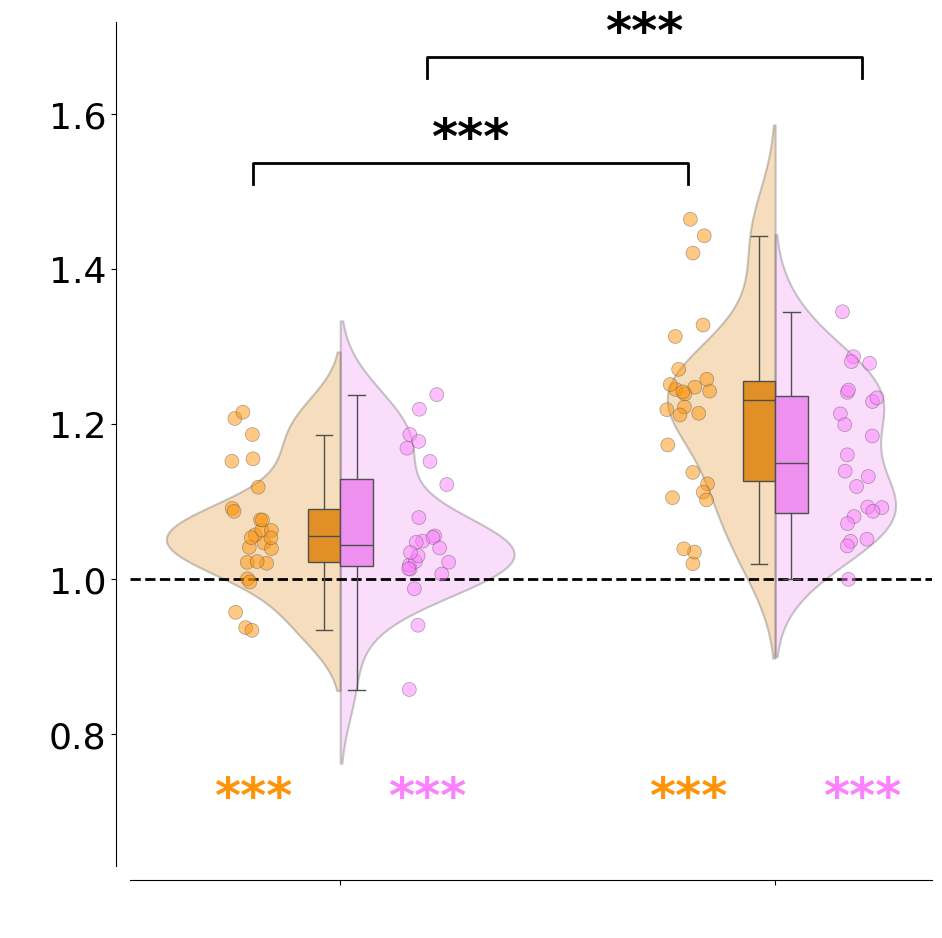

/tmp/ipykernel_348867/1348349382.py:138: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax, legend=False)


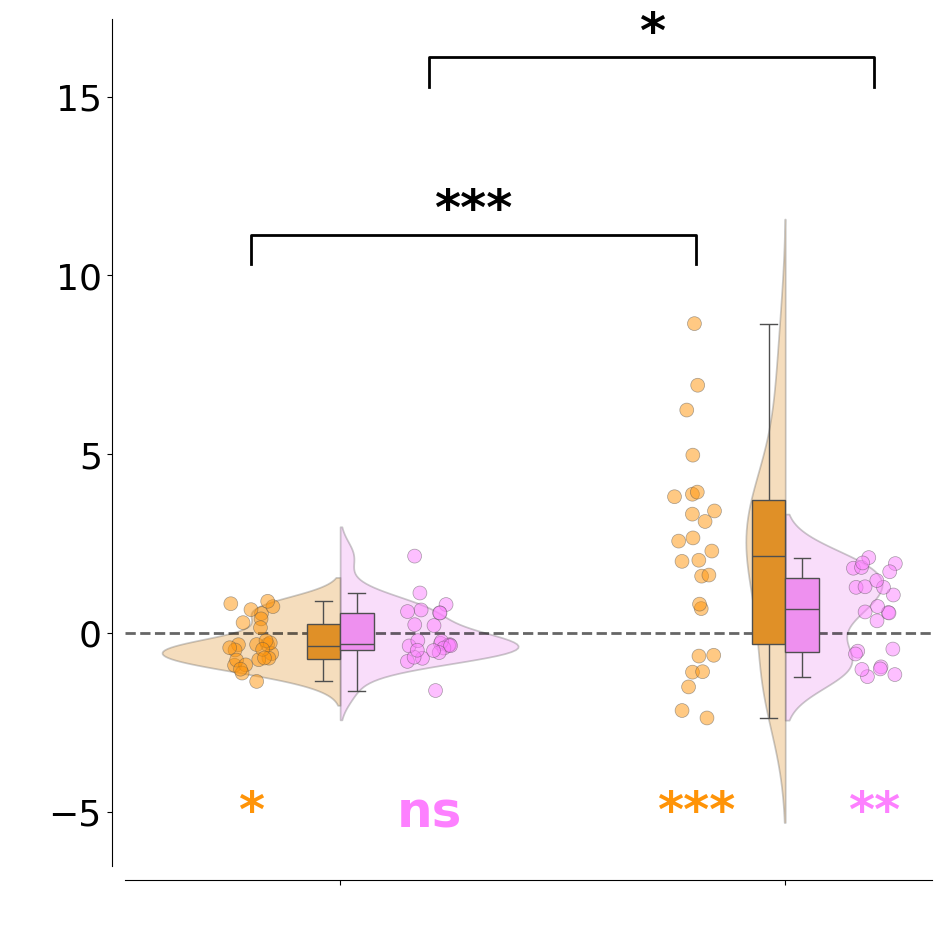

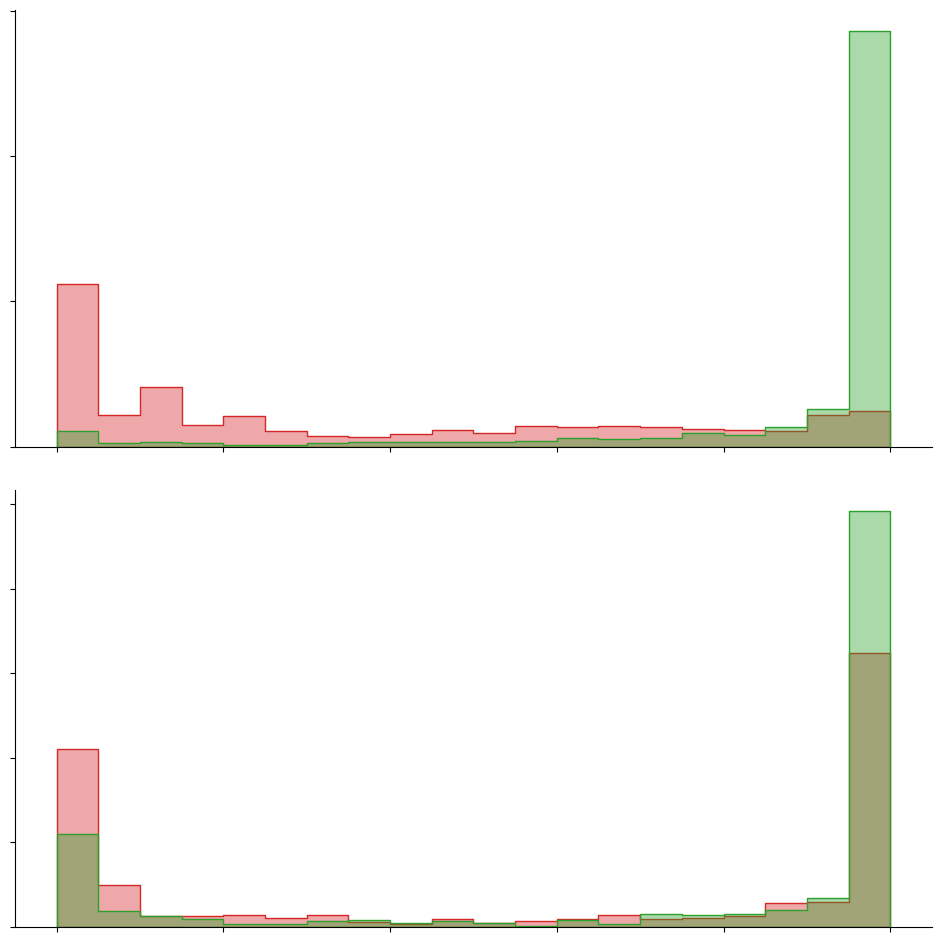

/tmp/ipykernel_348867/1348349382.py:208: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='task', y='auc', order=task_order, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
/tmp/ipykernel_348867/1348349382.py:209: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='task', y='auc', order=task_order, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
/tmp/ipykernel_348867/1348349382.py:210: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x='task', y='auc', order=task_order, palette=PALETTE, alpha=STRIP_ALPHA

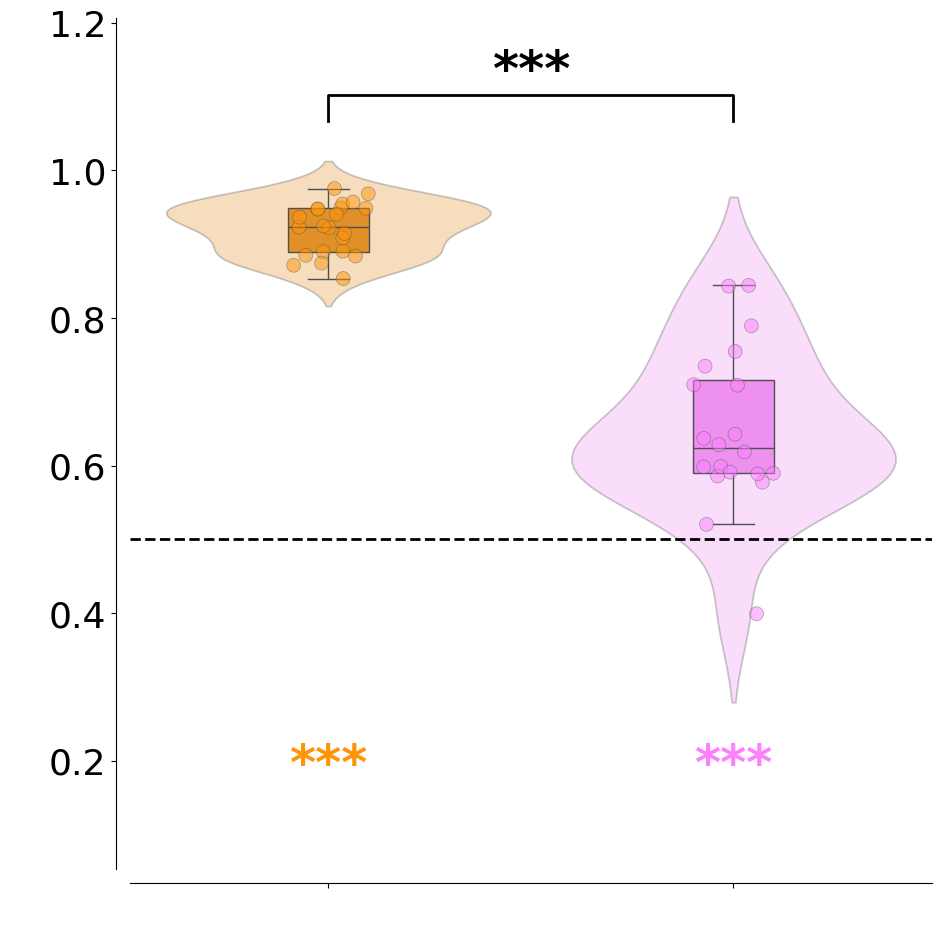

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon

# ============================================================
# 0. Global Setup & Plot Parameters
# ============================================================
input_dir = './indiv_dvals/'
slsqp = True  # Toggle for monotonic constraints

output_dir = os.path.join(os.getcwd(), 'vf_slsqp_noVPRpen')
solver_method = 'SLSQP'

# Global Styling Configuration
FS_TITLE = 24
FS_LABEL = 24
FS_TICK = 26
FS_LEGEND = 16
FS_STARS = 36  # (1) Increased star size significantly
FS_PVAL = 14

PALETTE = {'active': '#FF9408', 'passive': '#FD80FF'}
ROI_ORDER = ['A1', 'NoA1']
VIOLIN_ALPHA = 0.3
STRIP_ALPHA = 0.5
STRIP_SIZE = 10 

plt.rcParams.update({
    'font.size': FS_TICK,
    'axes.labelsize': FS_LABEL,
    'axes.titlesize': FS_TITLE,
    'xtick.labelsize': FS_TICK,
    'ytick.labelsize': FS_TICK,
    'legend.fontsize': FS_LEGEND,
})

# Data Ingestion
df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))
df_vpr = pd.read_csv('all_vpr_scores_all.csv')

# Helper Functions
def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def add_bracket(ax, x1, x2, y, h, p):
    star = get_sig_star(p)
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=2, c='black')
    ax.text((x1+x2)*.5, y+h, star, ha='center', va='bottom', fontsize=FS_STARS, fontweight='bold')

def get_paired(df, col_group, val1, val2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = set(df[df[col_group] == val1][col_subj]) & set(df[df[col_group] == val2][col_subj])
    a = df[(df[col_group] == val1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group] == val2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# Figure 6A: Variability Peak Ratio (VPR) across ROIs
# ============================================================
def plot_figure_6a(df):
    df_plot = df.copy()
    roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
    df_plot['roi'] = df_plot['roi'].map(roi_map)
    roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
    task_order = ['active', 'passive']

    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df_plot, x='roi', y='vpr_score', hue='task', hue_order=task_order,
                   order=roi_order, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, linewidth=1.5, ax=ax, legend=False)
    sns.boxplot(data=df_plot, x='roi', y='vpr_score', hue='task', hue_order=task_order,
                order=roi_order, width=0.15, zorder=10, palette=PALETTE, showcaps=True, showfliers=False, ax=ax, legend=False)

    for patch in ax.patches:
        if isinstance(patch, plt.Polygon):
            patch.set_facecolor('none')
            patch.set_edgecolor('0.3')

    sns.stripplot(data=df_plot, x='roi', y='vpr_score', hue='task', hue_order=task_order,
                  order=roi_order, dodge=True, jitter=True, alpha=STRIP_ALPHA, palette=PALETTE,
                  size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax, legend=False)

    ax.axhline(1, color='black', ls='--', lw=2)
    y_min, y_max = df_plot['vpr_score'].min(), df_plot['vpr_score'].max()
    pad = (y_max - y_min) * 0.15

    # Regional comparisons (A1 vs NoA1)
    for task_idx, task in enumerate(task_order):
        g1 = df_plot[(df_plot['roi'] == roi_order[0]) & (df_plot['task'] == task)]['vpr_score'].dropna().values
        g2 = df_plot[(df_plot['roi'] == roi_order[1]) & (df_plot['task'] == task)]['vpr_score'].dropna().values
        if len(g1) == len(g2) and len(g1) > 0 and np.any(g1 - g2 != 0):
            _, p_val = wilcoxon(g1, g2)
        else:
            p_val = 1.0
        # (3) Corrected task offset logic so colors match x-position
        x1 = 0 - 0.2 if task == 'active' else 0 + 0.2
        x2 = 1 - 0.2 if task == 'active' else 1 + 0.2
        add_bracket(ax, x1, x2, y_max + pad * (0.5 + task_idx * 1.5), pad * 0.3, p_val)

    # One-sample tests vs Baseline (1.0)
    for i, roi in enumerate(roi_order):
        for task_idx, task in enumerate(task_order):
            vals = df_plot[(df_plot['roi'] == roi) & (df_plot['task'] == task)]['vpr_score'].dropna().values
            if len(vals) > 0 and np.any(vals - 1 != 0):
                _, p_vs1 = wilcoxon(vals - 1)
                star = get_sig_star(p_vs1)
            else:
                star = 'ns'
            # (3) Corrected color/position mapping for baseline stars
            x_pos = i - 0.2 if task == 'active' else i + 0.2
            ax.text(x_pos, y_min - pad * 1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    ax.set_ylim(bottom=y_min - pad * 2.5)
    plt.ylabel(' ', fontsize=FS_LABEL)
    plt.xlabel(' ', fontsize=FS_LABEL)
    ax.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    # (2) Appended _V2.png
    plt.savefig(os.path.join(output_dir, 'Fig6A_VPR_V2.png'), dpi=300)
    plt.show()

# ============================================================
# Figure 6B: Bifurcation Score across ROIs
# ============================================================
def plot_figure_6b(df):
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, split=True, inner=None, palette=PALETTE, alpha=VIOLIN_ALPHA, ax=ax, legend=False)
    sns.boxplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, width=0.15, zorder=10, palette=PALETTE, showfliers=False, ax=ax, legend=False)
    sns.stripplot(data=df, x='roi', y='score', hue='task', order=ROI_ORDER, dodge=True, alpha=STRIP_ALPHA, palette=PALETTE, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax, legend=False)

    ax.axhline(0, color='black', alpha=0.6, lw=2, linestyle='--')
    y_min, y_max = df['score'].min(), df['score'].max()
    pad = (y_max - y_min) * 0.15

    # One-sample test vs 0
    for i, roi in enumerate(ROI_ORDER):
        alt = 'less' if roi == 'A1' else 'greater'
        for j, task in enumerate(['active', 'passive']):
            vals = df[(df['roi'] == roi) & (df['task'] == task)]['score'].dropna().values
            if len(vals) > 0 and np.any(vals != 0):
                _, p1 = wilcoxon(vals, alternative=alt)
                star = get_sig_star(p1)
            else:
                star = 'ns'
            x_pos = i - 0.2 if j == 0 else i + 0.2
            ax.text(x_pos, y_min - pad * 1.2, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[task])

    # Paired ROI comparisons
    for j, task in enumerate(['active', 'passive']):
        a1, no = get_paired(df, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
        if len(a1) > 0 and np.any(no - a1 != 0):
            _, p1 = wilcoxon(no, a1, alternative='greater')
            x_off = -0.2 if j == 0 else 0.2
            add_bracket(ax, 0 + x_off, 1 + x_off, y_max + pad * (1 + j * 3), pad * 0.5, p1)

    ax.set_ylim(bottom=y_min - pad * 2.5)
    plt.ylabel(' ', fontsize=FS_LABEL)
    plt.xlabel(' ', fontsize=FS_LABEL)
    ax.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    # (2) Appended _V2.png
    plt.savefig(os.path.join(output_dir, 'Fig6B_Bifurcation_V2.png'), dpi=300)
    plt.show()

# ============================================================
# Figure 6C: Distribution of Predicted Audibility (Step Histograms)
# ============================================================
def plot_figure_6c(df):
    fig, axes = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    df_plot = df.copy()
    df_plot['Report'] = df_plot['HnotH'].map({1.0: 'Heard', 0.0: 'Not Heard'})

    for i, task in enumerate(['active', 'passive']):
        sub = df_plot[df_plot['task'] == task]
        sns.histplot(data=sub, x='post_high', hue='Report',
                     palette={'Heard': '#2ca02c', 'Not Heard': '#d62728'},
                     stat='density', common_norm=False, ax=axes[i],
                     alpha=0.4, bins=20, binrange=(0, 1), element="step", legend=False)

        axes[i].set_title("")
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].yaxis.set_ticklabels([])
        axes[i].xaxis.set_ticklabels([])

    sns.despine()
    plt.tight_layout()
    # (2) Appended _V2.png
    plt.savefig(os.path.join(output_dir, 'Fig6C_Posteriors_V2.png'), dpi=300)
    plt.show()

# ============================================================
# Figure 6D: Single-trial Prediction Sensitivity (AUC)
# ============================================================
def plot_figure_6d(df):
    task_order = ['active', 'passive']
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.violinplot(data=df, x='task', y='auc', order=task_order, palette=PALETTE, inner=None, alpha=VIOLIN_ALPHA, ax=ax)
    sns.boxplot(data=df, x='task', y='auc', order=task_order, width=0.2, palette=PALETTE, showfliers=False, ax=ax)
    sns.stripplot(data=df, x='task', y='auc', order=task_order, palette=PALETTE, alpha=STRIP_ALPHA, size=STRIP_SIZE, edgecolor='gray', linewidth=0.5, ax=ax)

    ax.axhline(0.5, color='black', ls='--', lw=2)
    y_min, y_max = df['auc'].min(), df['auc'].max()
    
    # (4) Expanded bottom padding & lower y-limit to decouple stars from passive plot
    pad = (y_max - y_min) * 0.20

    # Paired task comparison
    act, pas = get_paired(df, 'task', 'active', 'passive', 'subj', 'auc')
    if len(act) > 0 and np.any(act - pas != 0):
        _, p1 = wilcoxon(act, pas, alternative='greater')
        add_bracket(ax, 0, 1, y_max + pad * 0.8, pad * 0.3, p1)

    # One-sample test vs Baseline (0.5)
    for i, t in enumerate(task_order):
        vals = df[df['task'] == t]['auc'].dropna().values
        if len(vals) > 0 and np.any(vals - 0.5 != 0):
            _, p_vs_chance = wilcoxon(vals - 0.5, alternative='greater')
            star = get_sig_star(p_vs_chance)
        else:
            star = 'ns'
        # (4) Pushed stars lower below y_min
        ax.text(i, y_min - pad * 1.5, star, ha='center', va='top', fontsize=FS_STARS, fontweight='bold', color=PALETTE[t])

    # (4) Explicitly set y-axis limits to guarantee clean breathing room
    ax.set_ylim(bottom=y_min - pad * 3.0, top=y_max + pad * 2.0)

    plt.ylabel(' ', fontsize=FS_LABEL)
    plt.xlabel(' ', fontsize=FS_LABEL)
    ax.xaxis.set_ticklabels([])
    sns.despine(offset=10)
    plt.tight_layout()
    # (2) Appended _V2.png
    plt.savefig(os.path.join(output_dir, 'Fig6D_AUC_V2.png'), dpi=300)
    plt.show()

# ============================================================
# Main Execution Pipeline
# ============================================================
if __name__ == '__main__':
    plot_figure_6a(df_vpr)
    plot_figure_6b(df_bif)
    plot_figure_6c(df_trials)
    plot_figure_6d(df_auc)

# statzzzzz

In [2]:
import os
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

# ============================================================
# Setup Paths & Load Data
# ============================================================
output_dir = os.path.join(os.getcwd(), 'vf_slsqp_noVPRpen')

df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_vpr = pd.read_csv('all_vpr_scores_all.csv')

# Helper Functions
def get_sig_star(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def print_summary_stats(label, values):
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)
    median_val = np.median(values)
    q25, q75 = np.percentile(values, [25, 75])
    iqr_val = q75 - q25
    print(f"  [{label}] N={len(values)}")
    print(f"    - Mean (SD) : {mean_val:.4f} ({std_val:.4f})")
    print(f"    - Median    : {median_val:.4f} [IQR: {q25:.4f} to {q75:.4f}, diff={iqr_val:.4f}]")

def get_paired(df, col_group, val1, val2, col_subj, col_score, col_filter=None, filter_val=None):
    if col_filter:
        df = df[df[col_filter] == filter_val]
    common = set(df[df[col_group] == val1][col_subj]) & set(df[df[col_group] == val2][col_subj])
    a = df[(df[col_group] == val1) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    b = df[(df[col_group] == val2) & (df[col_subj].isin(common))].sort_values(col_subj)[col_score].values
    return a, b

# ============================================================
# Print Figures Summary & Detailed Statistics
# ============================================================
print("================================================================")
print("             SUMMARY OF FIGURE DISPLAY PARAMETERS               ")
print("================================================================")
print(" * Violin plots: Show full empirical distribution (density).")
print(" * Boxplots    : Center line = MEDIAN | Box = IQR (25th to 75th percentile).")
print(" * Stripplot   : Displays individual subject data points.")
print(" * Stars       : Based on Wilcoxon signed-rank tests.\n")

# ------------------------------------------------------------
# Figure 6A: VPR Scores
# ------------------------------------------------------------
print("================================================================")
print("FIGURE 6A: Variability Peak Ratio (VPR)")
print("================================================================")
roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr_clean = df_vpr.copy()
df_vpr_clean['roi'] = df_vpr_clean['roi'].map(roi_map)
roi_order = ['Primary Audit.', 'Beyond Primary Audit.']
task_order = ['active', 'passive']

# 1. Descriptive Stats
for roi in roi_order:
    for task in task_order:
        vals = df_vpr_clean[(df_vpr_clean['roi'] == roi) & (df_vpr_clean['task'] == task)]['vpr_score'].dropna().values
        print_summary_stats(f"{roi} - {task.upper()}", vals)

# 2. One-sample Wilcoxon vs Baseline = 1.0
print("\n--- One-Sample Wilcoxon Tests vs Baseline (1.0) ---")
for roi in roi_order:
    for task in task_order:
        vals = df_vpr_clean[(df_vpr_clean['roi'] == roi) & (df_vpr_clean['task'] == task)]['vpr_score'].dropna().values
        if len(vals) > 0 and np.any(vals - 1 != 0):
            res = wilcoxon(vals - 1)
            print(f"  {roi} ({task.upper()}) vs 1.0: Stat={res.statistic:.2f}, p={res.pvalue:.5f} ({get_sig_star(res.pvalue)})")

# 3. Regional Paired Comparisons (A1 vs NoA1)
print("\n--- Regional Paired Comparisons (Primary vs Beyond) ---")
for task in task_order:
    g1 = df_vpr_clean[(df_vpr_clean['roi'] == roi_order[0]) & (df_vpr_clean['task'] == task)]['vpr_score'].dropna().values
    g2 = df_vpr_clean[(df_vpr_clean['roi'] == roi_order[1]) & (df_vpr_clean['task'] == task)]['vpr_score'].dropna().values
    if len(g1) == len(g2) and len(g1) > 0 and np.any(g1 - g2 != 0):
        res = wilcoxon(g1, g2)
        print(f"  {task.upper()} (Primary vs Beyond): Stat={res.statistic:.2f}, p={res.pvalue:.5f} ({get_sig_star(res.pvalue)})")

# ------------------------------------------------------------
# Figure 6B: Bifurcation Score
# ------------------------------------------------------------
print("\n================================================================")
print("FIGURE 6B: Bifurcation Score")
print("================================================================")
# 1. Descriptive Stats
for roi in ['A1', 'NoA1']:
    for task in task_order:
        vals = df_bif[(df_bif['roi'] == roi) & (df_bif['task'] == task)]['score'].dropna().values
        print_summary_stats(f"{roi} - {task.upper()}", vals)

# 2. Directional One-sample Wilcoxon vs 0
print("\n--- One-Sample Wilcoxon Tests vs Baseline (0.0) ---")
for roi in ['A1', 'NoA1']:
    alt = 'less' if roi == 'A1' else 'greater'
    for task in task_order:
        vals = df_bif[(df_bif['roi'] == roi) & (df_bif['task'] == task)]['score'].dropna().values
        if len(vals) > 0 and np.any(vals != 0):
            res = wilcoxon(vals, alternative=alt)
            print(f"  {roi} ({task.upper()}) vs 0.0 [{alt}]: Stat={res.statistic:.2f}, p={res.pvalue:.5f} ({get_sig_star(res.pvalue)})")

# 3. Paired Regional Comparison (NoA1 > A1)
print("\n--- Paired Regional Comparisons (NoA1 > A1) ---")
for task in task_order:
    a1, no = get_paired(df_bif, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=task)
    if len(a1) > 0 and np.any(no - a1 != 0):
        res = wilcoxon(no, a1, alternative='greater')
        print(f"  {task.upper()} (NoA1 > A1): Stat={res.statistic:.2f}, p={res.pvalue:.5f} ({get_sig_star(res.pvalue)})")

# ------------------------------------------------------------
# Figure 6D: AUC Single-Trial Sensitivity
# ------------------------------------------------------------
print("\n================================================================")
print("FIGURE 6D: Single-Trial AUC Sensitivity")
print("================================================================")
# 1. Descriptive Stats
for task in task_order:
    vals = df_auc[df_auc['task'] == task]['auc'].dropna().values
    print_summary_stats(f"AUC - {task.upper()}", vals)

# 2. One-sample Wilcoxon vs Chance (0.5)
print("\n--- One-Sample Wilcoxon Tests vs Chance (0.5) [greater] ---")
for task in task_order:
    vals = df_auc[df_auc['task'] == task]['auc'].dropna().values
    if len(vals) > 0 and np.any(vals - 0.5 != 0):
        res = wilcoxon(vals - 0.5, alternative='greater')
        print(f"  {task.upper()} vs 0.5: Stat={res.statistic:.2f}, p={res.pvalue:.5f} ({get_sig_star(res.pvalue)})")

# 3. Paired Task Comparison (Active > Passive)
print("\n--- Paired Task Comparison (Active > Passive) ---")
act, pas = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
if len(act) > 0 and np.any(act - pas != 0):
    res = wilcoxon(act, pas, alternative='greater')
    print(f"  AUC (Active > Passive): Stat={res.statistic:.2f}, p={res.pvalue:.5f} ({get_sig_star(res.pvalue)})\n")

             SUMMARY OF FIGURE DISPLAY PARAMETERS               
 * Violin plots: Show full empirical distribution (density).
 * Boxplots    : Center line = MEDIAN | Box = IQR (25th to 75th percentile).
 * Stripplot   : Displays individual subject data points.
 * Stars       : Based on Wilcoxon signed-rank tests.

FIGURE 6A: Variability Peak Ratio (VPR)
  [Primary Audit. - ACTIVE] N=26
    - Mean (SD) : 1.0643 (0.0746)
    - Median    : 1.0552 [IQR: 1.0218 to 1.0903, diff=0.0685]
  [Primary Audit. - PASSIVE] N=24
    - Mean (SD) : 1.0639 (0.0899)
    - Median    : 1.0438 [IQR: 1.0168 to 1.1295, diff=0.1126]
  [Beyond Primary Audit. - ACTIVE] N=26
    - Mean (SD) : 1.2183 (0.1170)
    - Median    : 1.2305 [IQR: 1.1265 to 1.2561, diff=0.1296]
  [Beyond Primary Audit. - PASSIVE] N=24
    - Mean (SD) : 1.1606 (0.0939)
    - Median    : 1.1498 [IQR: 1.0858 to 1.2356, diff=0.1499]

--- One-Sample Wilcoxon Tests vs Baseline (1.0) ---
  Primary Audit. (ACTIVE) vs 1.0: Stat=39.00, p=0.00022 (**

# treeBiatcH

In [3]:
import os
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon

output_dir = os.path.join(os.getcwd(), 'vf_slsqp_noVPRpen')

# --- Helper Functions for TreeBH ---
def simes_p(p_vals):
    p_sorted = np.sort(np.asarray(p_vals))
    n = len(p_sorted)
    if n == 0: return 1.0
    return np.min((n / np.arange(1, n + 1)) * p_sorted)

def bh_correct(p_vals, alpha=0.05):
    p = np.asarray(p_vals)
    m = len(p)
    if m == 0: return np.array([]), np.array([], dtype=bool)
    
    sorted_idx = np.argsort(p)
    p_sorted = p[sorted_idx]
    thresholds = (np.arange(1, m + 1) / m) * alpha
    
    sig_sorted = p_sorted <= thresholds
    max_sig = np.where(sig_sorted)[0]
    
    sig = np.zeros(m, dtype=bool)
    if len(max_sig) > 0:
        sig[sorted_idx[:max_sig[-1] + 1]] = True
        
    p_adj_sorted = np.zeros(m)
    cum_min = 1.0
    for i in range(m - 1, -1, -1):
        cum_min = min(cum_min, p_sorted[i] * m / (i + 1))
        p_adj_sorted[i] = cum_min
        
    p_adj = np.zeros(m)
    p_adj[sorted_idx] = p_adj_sorted
    return p_adj, sig

def get_paired(df, group_col, g1_val, g2_val, subj_col, val_col, col_filter=None, filter_val=None):
    if col_filter:
        sub = df[df[col_filter] == filter_val]
    else:
        sub = df.copy()
    p1 = sub[sub[group_col] == g1_val][[subj_col, val_col]].rename(columns={val_col: 'val1'})
    p2 = sub[sub[group_col] == g2_val][[subj_col, val_col]].rename(columns={val_col: 'val2'})
    merged = pd.merge(p1, p2, on=subj_col).dropna()
    return merged['val1'].values, merged['val2'].values

# --- 0. Load Data & Standardize Subject Column Names ---
df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))
df_vpr = pd.read_csv('all_vpr_scores_all.csv')

for df in [df_bif, df_auc, df_trials, df_vpr]:
    df.rename(columns={'subject': 'subj', 'sub': 'subj', 'participant': 'subj'}, inplace=True)

roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr_proc = df_vpr.copy()
df_vpr_proc['roi_mapped'] = df_vpr_proc['roi'].map(roi_map)

# --- 1. Compute Raw Wilcoxon P-Values (15 Corrected Tests) ---

# Metric 1: VPR
vpr_raw = {}
for r_raw, r_clean in roi_map.items():
    for t in ['active', 'passive']:
        v = df_vpr_proc[(df_vpr_proc['roi_mapped'] == r_clean) & (df_vpr_proc['task'] == t)]['vpr_score'].dropna().values
        _, p = wilcoxon(v - 1.0)
        vpr_raw[f'vpr_base_{r_raw}_{t}'] = p

for t in ['active', 'passive']:
    g1, g2 = get_paired(df_vpr_proc, 'roi_mapped', roi_map['A1'], roi_map['NoA1'], 'subj', 'vpr_score', col_filter='task', filter_val=t)
    _, p = wilcoxon(g1, g2)
    vpr_raw[f'vpr_roi_{t}'] = p

# Metric 2: Bifurcation Score
bif_raw = {}
for r in ['A1', 'NoA1']:
    alt = 'less' if r == 'A1' else 'greater'
    for t in ['active', 'passive']:
        v = df_bif[(df_bif['roi'] == r) & (df_bif['task'] == t)]['score'].dropna().values
        _, p = wilcoxon(v, alternative=alt)
        bif_raw[f'bif_base_{r}_{t}'] = p

for t in ['active', 'passive']:
    g1, g2 = get_paired(df_bif, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=t)
    _, p = wilcoxon(g1, g2)
    bif_raw[f'bif_roi_{t}'] = p

# Metric 3: AUC Sensitivity
auc_raw = {}
for t in ['active', 'passive']:
    v = df_auc[df_auc['task'] == t]['auc'].dropna().values
    _, p = wilcoxon(v - 0.5, alternative='greater')
    auc_raw[f'auc_base_{t}'] = p

act_auc, pas_auc = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
_, p = wilcoxon(act_auc, pas_auc, alternative='greater')
auc_raw['auc_task_act_vs_pass'] = p

# --- 2. Hierarchical TreeBH Pipeline ---

# LEVEL 1: Metric Level
p_l1_raw = [simes_p(list(vpr_raw.values())), simes_p(list(bif_raw.values())), simes_p(list(auc_raw.values()))]
p_l1_adj, l1_sig = bh_correct(p_l1_raw, alpha=0.05)

metrics = ['VPR', 'Bifurcation', 'AUC']
print("=== LEVEL 1: METRIC-LEVEL RESULTS ===")
for m_name, p_r, p_a, s in zip(metrics, p_l1_raw, p_l1_adj, l1_sig):
    print(f"Metric: {m_name:<12} | Simes p: {p_r:.5e} | Adj p: {p_a:.5e} | Pass: {s}")

# Define Sub-family Configs for Level 2 & Level 3
subfamilies_config = [
    {'metric': 'VPR', 'sub': 'Baseline vs 1.0', 'raw_dict': {k: v for k, v in vpr_raw.items() if 'base' in k}, 'l1_pass': l1_sig[0]},
    {'metric': 'VPR', 'sub': 'A1 vs NoA1', 'raw_dict': {k: v for k, v in vpr_raw.items() if 'roi' in k}, 'l1_pass': l1_sig[0]},
    {'metric': 'Bifurcation', 'sub': 'Baseline vs 0.0', 'raw_dict': {k: v for k, v in bif_raw.items() if 'base' in k}, 'l1_pass': l1_sig[1]},
    {'metric': 'Bifurcation', 'sub': 'A1 vs NoA1', 'raw_dict': {k: v for k, v in bif_raw.items() if 'roi' in k}, 'l1_pass': l1_sig[1]},
    {'metric': 'AUC', 'sub': 'Baseline vs 0.5', 'raw_dict': {k: v for k, v in auc_raw.items() if 'base' in k}, 'l1_pass': l1_sig[2]},
    {'metric': 'AUC', 'sub': 'Active vs Passive', 'raw_dict': {k: v for k, v in auc_raw.items() if 'task' in k}, 'l1_pass': l1_sig[2]}
]

# LEVEL 2: Compute Raw Simes P-values across Sub-families
level2_intermediate = []
for item in subfamilies_config:
    if item['l1_pass']:
        raw_p_list = list(item['raw_dict'].values())
        s_p = simes_p(raw_p_list)
    else:
        s_p = 1.0
    item['l2_simes_p'] = s_p
    level2_intermediate.append(item)

# LEVEL 2: Apply BH Correction across Sub-families per Parent Metric
level2_results = []
final_tree_results = []

for m_name in metrics:
    m_subfams = [item for item in level2_intermediate if item['metric'] == m_name]
    l2_raw_ps = [item['l2_simes_p'] for item in m_subfams]
    
    # Adjust Level 2 Simes p-values
    l2_adj_ps, l2_sigs = bh_correct(l2_raw_ps, alpha=0.05)
    
    for item, l2_p_adj, l2_pass in zip(m_subfams, l2_adj_ps, l2_sigs):
        # Override pass state if L1 failed
        if not item['l1_pass']:
            l2_p_adj = 1.0
            l2_pass = False
            
        level2_results.append({
            'Metric': item['metric'],
            'SubFamily': item['sub'],
            'Simes_p': item['l2_simes_p'],
            'Simes_p_adj': l2_p_adj,
            'Pass': l2_pass
        })
        
        # LEVEL 3: Individual Test Corrections (Gated by L2 Pass)
        raw_dict = item['raw_dict']
        p_vals = list(raw_dict.values())
        
        if l2_pass:
            p_adj_l3, sig_l3 = bh_correct(p_vals, alpha=0.05)
            for k, p_raw, p_a, s in zip(raw_dict.keys(), p_vals, p_adj_l3, sig_l3):
                final_tree_results.append({
                    'Metric': item['metric'],
                    'SubFamily': item['sub'],
                    'Test': k,
                    'Raw_p': p_raw,
                    'L2_Simes_p_adj': l2_p_adj,
                    'Adj_p': p_a,
                    'Sig': s
                })
        else:
            for k, p_raw in raw_dict.items():
                final_tree_results.append({
                    'Metric': item['metric'],
                    'SubFamily': item['sub'],
                    'Test': k,
                    'Raw_p': p_raw,
                    'L2_Simes_p_adj': l2_p_adj,
                    'Adj_p': 1.0,
                    'Sig': False
                })

# --- PRINT LEVEL 2 RESULTS ---
df_l2_summary = pd.DataFrame(level2_results)
print("\n=== LEVEL 2: SUB-FAMILY RESULTS ===")
print(df_l2_summary.to_string(index=False))

# --- PRINT LEVEL 3 RESULTS ---
df_tree_summary = pd.DataFrame(final_tree_results)
print("\n=== LEVEL 3: INDIVIDUAL TEST RESULTS ===")
print(df_tree_summary.to_string(index=False))

=== LEVEL 1: METRIC-LEVEL RESULTS ===
Metric: VPR          | Simes p: 1.78814e-07 | Adj p: 5.36442e-07 | Pass: True
Metric: Bifurcation  | Simes p: 1.39529e-03 | Adj p: 1.39529e-03 | Pass: True
Metric: AUC          | Simes p: 7.15256e-07 | Adj p: 1.07288e-06 | Pass: True

=== LEVEL 2: SUB-FAMILY RESULTS ===
     Metric         SubFamily      Simes_p  Simes_p_adj  Pass
        VPR   Baseline vs 1.0 1.192093e-07 2.384186e-07  True
        VPR        A1 vs NoA1 1.132488e-06 1.132488e-06  True
Bifurcation   Baseline vs 0.0 1.181483e-03 1.181483e-03  True
Bifurcation        A1 vs NoA1 9.301901e-04 1.181483e-03  True
        AUC   Baseline vs 0.5 4.768372e-07 9.536743e-07  True
        AUC Active vs Passive 9.536743e-07 9.536743e-07  True

=== LEVEL 3: INDIVIDUAL TEST RESULTS ===
     Metric         SubFamily                  Test        Raw_p  L2_Simes_p_adj        Adj_p   Sig
        VPR   Baseline vs 1.0    vpr_base_A1_active 2.174675e-04    2.384186e-07 2.899567e-04  True
        VPR   B

# treeBiatcH tables

In [9]:
import os
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

output_dir = os.path.join(os.getcwd(), 'vf_slsqp_noVPRpen')
output_xlsx_path = os.path.join(output_dir, 'TreeBH_Statistical_Summary_Paper.xlsx')

# --- 1. Helper Functions ---

def simes_p(p_vals):
    p_sorted = np.sort(np.asarray(p_vals))
    n = len(p_sorted)
    if n == 0: return 1.0
    return np.min((n / np.arange(1, n + 1)) * p_sorted)

def bh_correct(p_vals, alpha=0.05):
    p = np.asarray(p_vals)
    m = len(p)
    if m == 0: return np.array([]), np.array([], dtype=bool)
    
    sorted_idx = np.argsort(p)
    p_sorted = p[sorted_idx]
    thresholds = (np.arange(1, m + 1) / m) * alpha
    
    sig_sorted = p_sorted <= thresholds
    max_sig = np.where(sig_sorted)[0]
    
    sig = np.zeros(m, dtype=bool)
    if len(max_sig) > 0:
        sig[sorted_idx[:max_sig[-1] + 1]] = True
        
    p_adj_sorted = np.zeros(m)
    cum_min = 1.0
    for i in range(m - 1, -1, -1):
        cum_min = min(cum_min, p_sorted[i] * m / (i + 1))
        p_adj_sorted[i] = cum_min
        
    p_adj = np.zeros(m)
    p_adj[sorted_idx] = p_adj_sorted
    return p_adj, sig

def get_paired(df, group_col, g1_val, g2_val, subj_col, val_col, col_filter=None, filter_val=None):
    if col_filter:
        sub = df[df[col_filter] == filter_val]
    else:
        sub = df.copy()
    p1 = sub[sub[group_col] == g1_val][[subj_col, val_col]].rename(columns={val_col: 'val1'})
    p2 = sub[sub[group_col] == g2_val][[subj_col, val_col]].rename(columns={val_col: 'val2'})
    merged = pd.merge(p1, p2, on=subj_col).dropna()
    return merged['val1'].values, merged['val2'].values

# --- 2. Load Data ---

df_bif = pd.read_csv(os.path.join(output_dir, 'bifScore.csv'))
df_auc = pd.read_csv(os.path.join(output_dir, 'prediction_auc.csv'))
df_trials = pd.read_csv(os.path.join(output_dir, 'trials.csv'))
df_vpr = pd.read_csv('all_vpr_scores_all.csv')

for df in [df_bif, df_auc, df_trials, df_vpr]:
    df.rename(columns={'subject': 'subj', 'sub': 'subj', 'participant': 'subj'}, inplace=True)

roi_map = {'A1': 'Primary Audit.', 'NoA1': 'Beyond Primary Audit.'}
df_vpr_proc = df_vpr.copy()
df_vpr_proc['roi_mapped'] = df_vpr_proc['roi'].map(roi_map)

# --- 3. Compute Wilcoxon P-Values ---

vpr_raw = {}
for r_raw, r_clean in roi_map.items():
    for t in ['active', 'passive']:
        v = df_vpr_proc[(df_vpr_proc['roi_mapped'] == r_clean) & (df_vpr_proc['task'] == t)]['vpr_score'].dropna().values
        _, p = wilcoxon(v - 1.0)
        vpr_raw[f'vpr_base_{r_raw}_{t}'] = p

for t in ['active', 'passive']:
    g1, g2 = get_paired(df_vpr_proc, 'roi_mapped', roi_map['A1'], roi_map['NoA1'], 'subj', 'vpr_score', col_filter='task', filter_val=t)
    _, p = wilcoxon(g1, g2)
    vpr_raw[f'vpr_roi_{t}'] = p

bif_raw = {}
for r in ['A1', 'NoA1']:
    alt = 'less' if r == 'A1' else 'greater'
    for t in ['active', 'passive']:
        v = df_bif[(df_bif['roi'] == r) & (df_bif['task'] == t)]['score'].dropna().values
        _, p = wilcoxon(v, alternative=alt)
        bif_raw[f'bif_base_{r}_{t}'] = p

for t in ['active', 'passive']:
    g1, g2 = get_paired(df_bif, 'roi', 'A1', 'NoA1', 'subj', 'score', col_filter='task', filter_val=t)
    _, p = wilcoxon(g1, g2)
    bif_raw[f'bif_roi_{t}'] = p

auc_raw = {}
for t in ['active', 'passive']:
    v = df_auc[df_auc['task'] == t]['auc'].dropna().values
    _, p = wilcoxon(v - 0.5, alternative='greater')
    auc_raw[f'auc_base_{t}'] = p

act_auc, pas_auc = get_paired(df_auc, 'task', 'active', 'passive', 'subj', 'auc')
_, p = wilcoxon(act_auc, pas_auc, alternative='greater')
auc_raw['auc_task_act_vs_pass'] = p

# --- 4. Hierarchical TreeBH Corrections ---

metrics = ['VPR', 'Bifurcation', 'AUC']
p_l1_raw = [simes_p(list(vpr_raw.values())), simes_p(list(bif_raw.values())), simes_p(list(auc_raw.values()))]
p_l1_adj, l1_sig = bh_correct(p_l1_raw, alpha=0.05)

subfamilies_config = [
    {'metric': 'VPR', 'sub': 'Baseline vs 1.0', 'raw_dict': {k: v for k, v in vpr_raw.items() if 'base' in k}, 'l1_pass': l1_sig[0]},
    {'metric': 'VPR', 'sub': 'A1 vs NoA1', 'raw_dict': {k: v for k, v in vpr_raw.items() if 'roi' in k}, 'l1_pass': l1_sig[0]},
    {'metric': 'Bifurcation', 'sub': 'Baseline vs 0.0', 'raw_dict': {k: v for k, v in bif_raw.items() if 'base' in k}, 'l1_pass': l1_sig[1]},
    {'metric': 'Bifurcation', 'sub': 'A1 vs NoA1', 'raw_dict': {k: v for k, v in bif_raw.items() if 'roi' in k}, 'l1_pass': l1_sig[1]},
    {'metric': 'AUC', 'sub': 'Baseline vs 0.5', 'raw_dict': {k: v for k, v in auc_raw.items() if 'base' in k}, 'l1_pass': l1_sig[2]},
    {'metric': 'AUC', 'sub': 'Active vs Passive', 'raw_dict': {k: v for k, v in auc_raw.items() if 'task' in k}, 'l1_pass': l1_sig[2]}
]

level2_intermediate = []
for item in subfamilies_config:
    s_p = simes_p(list(item['raw_dict'].values())) if item['l1_pass'] else 1.0
    item['l2_simes_p'] = s_p
    level2_intermediate.append(item)

level2_results = []
final_tree_results = []

for m_name in metrics:
    m_subfams = [item for item in level2_intermediate if item['metric'] == m_name]
    l2_raw_ps = [item['l2_simes_p'] for item in m_subfams]
    l2_adj_ps, l2_sigs = bh_correct(l2_raw_ps, alpha=0.05)
    
    for item, l2_p_adj, l2_pass in zip(m_subfams, l2_adj_ps, l2_sigs):
        if not item['l1_pass']:
            l2_p_adj, l2_pass = 1.0, False
            
        level2_results.append({
            'Metric': item['metric'], 'SubFamily': item['sub'],
            'Simes_p': item['l2_simes_p'], 'Simes_p_adj': l2_p_adj, 'Pass': l2_pass
        })
        
        raw_dict = item['raw_dict']
        p_vals = list(raw_dict.values())
        m_tests = len(p_vals)
        
        if l2_pass:
            p_adj_l3, sig_l3 = bh_correct(p_vals, alpha=0.05)
            sorted_args = np.argsort(p_vals)
            ranks = np.zeros(m_tests, dtype=int)
            ranks[sorted_args] = np.arange(1, m_tests + 1)
            rev_alphas = (ranks / m_tests) * 0.05
            
            for k, p_raw, p_a, s, r_a in zip(raw_dict.keys(), p_vals, p_adj_l3, sig_l3, rev_alphas):
                final_tree_results.append({
                    'Metric': item['metric'], 'SubFamily': item['sub'], 'Test': k,
                    'Raw_p': p_raw, 'L2_Simes_p_adj': l2_p_adj, 'Adj_p': p_a, 'Rev_Alpha': r_a, 'Sig': s
                })
        else:
            for k, p_raw in raw_dict.items():
                final_tree_results.append({
                    'Metric': item['metric'], 'SubFamily': item['sub'], 'Test': k,
                    'Raw_p': p_raw, 'L2_Simes_p_adj': l2_p_adj, 'Adj_p': 1.0, 'Rev_Alpha': 0.0, 'Sig': False
                })

# --- 5. Export Functions ---

def build_treebh_summary_table(metrics, p_l1_raw, p_l1_adj, l1_sig, level2_results, final_tree_results):
    excel_rows = []
    excel_rows.append({
        'Level': 'LEVEL 1: METRIC-LEVEL (PARENT OMNIBUS)',
        'SubFamily / Test': '-', 'Raw P-value': '-', 'Adjusted P-value': '-',
        'Revised Alpha (m=3)': '-', 'Significant (alpha=0.05)': '-'
    })

    m_l1 = len(metrics)
    sorted_args_l1 = np.argsort(p_l1_raw)
    ranks_l1 = np.zeros(m_l1, dtype=int)
    ranks_l1[sorted_args_l1] = np.arange(1, m_l1 + 1)
    rev_alpha_l1 = (ranks_l1 / m_l1) * 0.05

    for m_name, p_r, p_a, r_a, s in zip(metrics, p_l1_raw, p_l1_adj, rev_alpha_l1, l1_sig):
        excel_rows.append({
            'Level': f'Metric: {m_name}', 'SubFamily / Test': 'Omnibus Simes Test',
            'Raw P-value': p_r, 'Adjusted P-value': p_a, 'Revised Alpha (m=3)': r_a,
            'Significant (alpha=0.05)': 'Yes' if s else 'No'
        })

    for m_name in metrics:
        excel_rows.append({
            'Level': f'--- LEVEL 2 & 3: {m_name.upper()} SUB-FAMILIES & TESTS ---',
            'SubFamily / Test': '', 'Raw P-value': '', 'Adjusted P-value': '',
            'Revised Alpha (m=3)': '', 'Significant (alpha=0.05)': ''
        })
        
        m_sub_items = [l2 for l2 in level2_results if l2['Metric'] == m_name]
        m_sub_count = len(m_sub_items)
        raw_sub_p = [l2['Simes_p'] for l2 in m_sub_items]
        sorted_args_sub = np.argsort(raw_sub_p)
        ranks_sub = np.zeros(m_sub_count, dtype=int)
        ranks_sub[sorted_args_sub] = np.arange(1, m_sub_count + 1)
        rev_alpha_sub = (ranks_sub / m_sub_count) * 0.05
        
        for l2_item, r_a_sub in zip(m_sub_items, rev_alpha_sub):
            sub_name = l2_item['SubFamily']
            excel_rows.append({
                'Level': 'Level 2 Sub-Family', 'SubFamily / Test': sub_name,
                'Raw P-value': l2_item['Simes_p'], 'Adjusted P-value': l2_item['Simes_p_adj'],
                'Revised Alpha (m=3)': r_a_sub if l2_item['Pass'] else 0.0,
                'Significant (alpha=0.05)': 'Passed' if l2_item['Pass'] else 'Failed'
            })
            
            l3_items = [l3 for l3 in final_tree_results if l3['Metric'] == m_name and l3['SubFamily'] == sub_name]
            for l3_item in l3_items:
                excel_rows.append({
                    'Level': '  Level 3 Test', 'SubFamily / Test': f"    {l3_item['Test']}",
                    'Raw P-value': l3_item['Raw_p'], 'Adjusted P-value': l3_item['Adj_p'],
                    'Revised Alpha (m=3)': l3_item['Rev_Alpha'],
                    'Significant (alpha=0.05)': 'Yes' if l3_item['Sig'] else 'No'
                })

    return pd.DataFrame(excel_rows)

def export_styled_excel(df, output_xlsx_path):
    wb = openpyxl.Workbook()
    ws = wb.active
    ws.title = "TreeBH Results Summary"

    header_fill = PatternFill(start_color="1F497D", end_color="1F497D", fill_type="solid")
    level1_fill = PatternFill(start_color="DCE6F1", end_color="DCE6F1", fill_type="solid")
    level2_fill = PatternFill(start_color="F2F2F2", end_color="F2F2F2", fill_type="solid")
    
    header_font = Font(name="Arial", size=11, bold=True, color="FFFFFF")
    section_font = Font(name="Arial", size=11, bold=True, color="1F497D")
    sub_font = Font(name="Arial", size=10, bold=True, color="000000")
    bold_font = Font(name="Arial", size=10, bold=True)
    regular_font = Font(name="Arial", size=10)

    thin_border = Border(
        left=Side(style='thin', color='D9D9D9'), right=Side(style='thin', color='D9D9D9'),
        top=Side(style='thin', color='D9D9D9'), bottom=Side(style='thin', color='D9D9D9')
    )

    headers = list(df.columns)
    ws.append(headers)

    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center", vertical="center")

    for r_idx, row in df.iterrows():
        row_vals = list(row.values)
        ws.append(row_vals)
        current_row = ws.max_row
        level_val = str(row_vals[0])

        if 'LEVEL' in level_val:
            ws.merge_cells(start_row=current_row, start_column=1, end_row=current_row, end_column=len(headers))
            cell = ws.cell(row=current_row, column=1)
            cell.fill = level1_fill
            cell.font = section_font
        elif 'Level 2 Sub-Family' in level_val:
            for c_idx in range(1, len(headers) + 1):
                cell = ws.cell(row=current_row, column=c_idx)
                cell.fill = level2_fill
                cell.font = sub_font
                cell.border = thin_border
        else:
            for c_idx in range(1, len(headers) + 1):
                cell = ws.cell(row=current_row, column=c_idx)
                cell.font = bold_font if 'Metric:' in level_val else regular_font
                cell.border = thin_border
                if c_idx >= 3 and isinstance(cell.value, (int, float)):
                    cell.number_format = '0.0000E+00' if 0 < cell.value < 0.001 else '0.0000'

    for col in ws.columns:
        max_len = max(len(str(cell.value or '')) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 4, 15)

    os.makedirs(os.path.dirname(output_xlsx_path), exist_ok=True)
    wb.save(output_xlsx_path)
    print(f"File successfully saved to: {output_xlsx_path}")

# --- 6. EXECUTE SAVING ---

df_summary = build_treebh_summary_table(metrics, p_l1_raw, p_l1_adj, l1_sig, level2_results, final_tree_results)
export_styled_excel(df_summary, output_xlsx_path)

File successfully saved to: /srv/elefanto/ConsciousnessTeam_Data/SOUNDFMRIxSOUNDMODEL/VFapril2026/review_and_cleaning_august26/vf_slsqp_noVPRpen/TreeBH_Statistical_Summary_Paper.xlsx


# parameter recovery v1

Simulating & Recovering: 100%|████████████████| 100/100 [00:46<00:00,  2.17it/s]


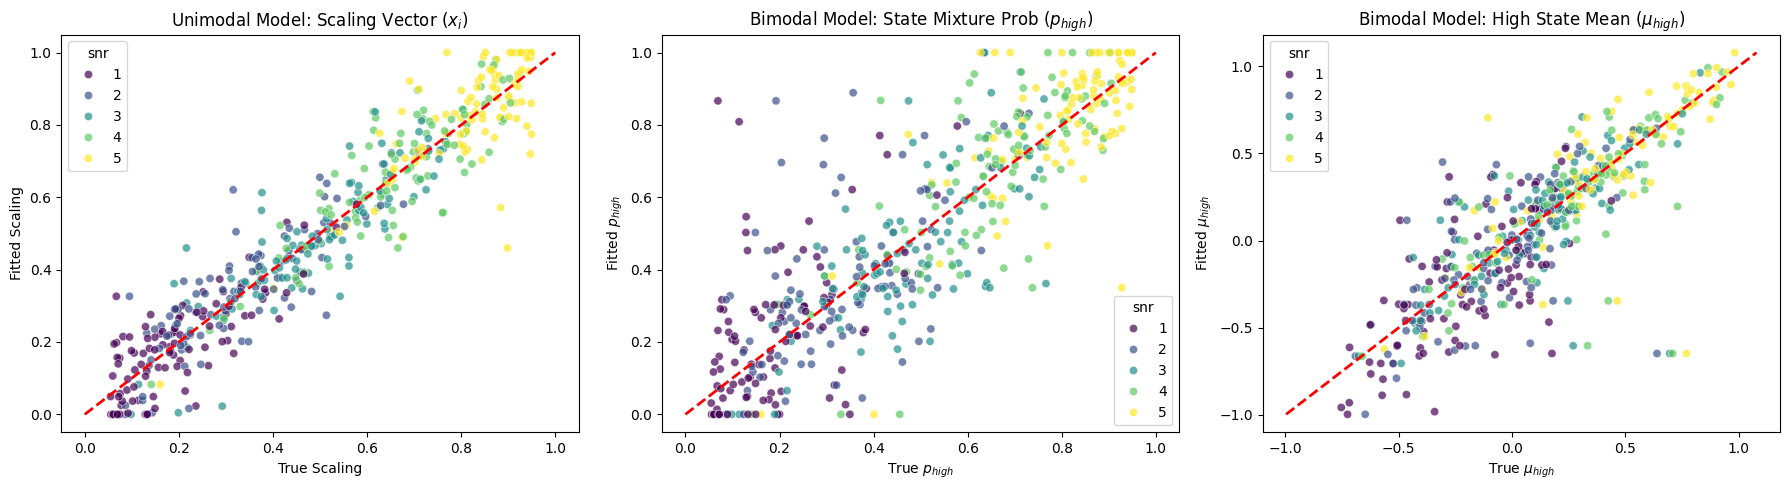

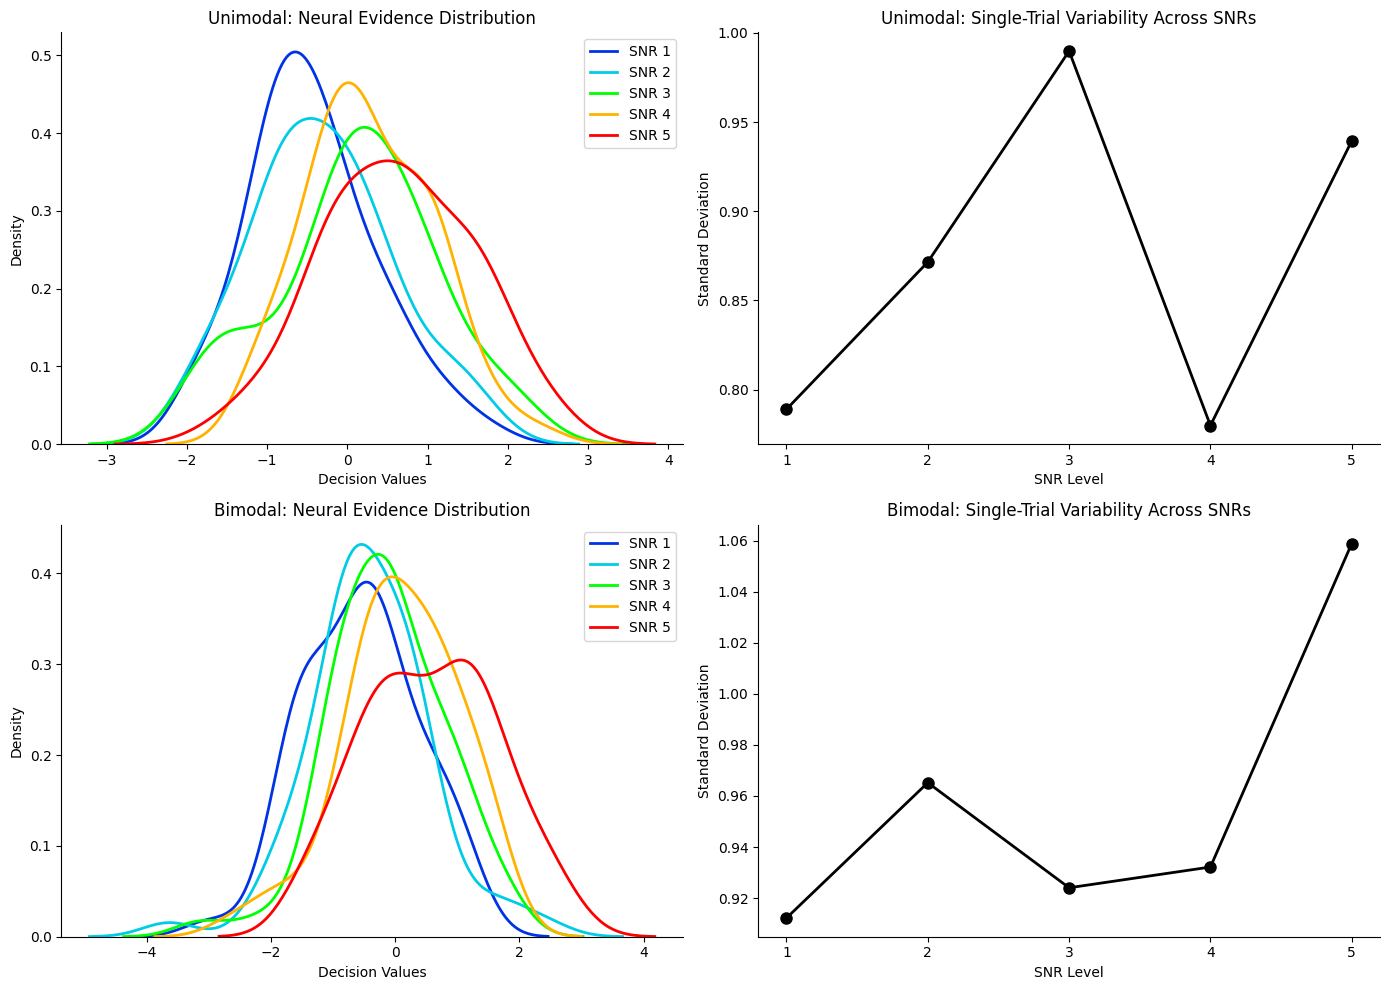

In [2]:
import os
import numpy as np
import pandas as pd
import scipy.stats
import scipy.special
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- Configuration & Paths ---
input_dir = './indiv_dvals/'
sim_output_dir = './simulation_recovery_results/'
os.makedirs(sim_output_dir, exist_ok=True)

participants = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 15, 18, 19, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30, 32]
snr_levels = np.array([1, 2, 3, 4, 5])

# --- Model & Constraint Helper Functions ---

def get_monotonic_constraints(start_idx, length=5):
    cons = []
    for i in range(start_idx, start_idx + length - 1):
        cons.append({'type': 'ineq', 'fun': lambda p, i=i: p[i+1] - p[i]})
    return cons

def get_llh_unimodal(x_vec, data, snr_list, mu_min, mu_max, sigma_snr):
    llh = 0
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        subset = data[snr_list == snr]
        if len(subset) == 0: continue
        mu = mu_min + x_vec[i] * (mu_max - mu_min)
        llh += np.sum(scipy.stats.norm.logpdf(subset, loc=mu, scale=sigma_snr))
    return llh

def get_llh_bimodal(pars, data, snr_list, mu_min, sigma_low, sigma_high):
    x_vec, mu_h_vec = pars[:5], pars[5:10]
    llh = 0
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        subset = data[snr_list == snr]
        if len(subset) == 0: continue
        l_low = scipy.stats.norm.logpdf(subset, loc=mu_min, scale=sigma_low)
        l_high = scipy.stats.norm.logpdf(subset, loc=mu_h_vec[i], scale=sigma_high)
        llh += np.sum(scipy.special.logsumexp(
            np.vstack([l_low + np.log(1 - x_vec[i] + 1e-9),
                       l_high + np.log(x_vec[i] + 1e-9)]), axis=0))
    return llh

# --- Step 1: Extract Empirical Parameter Distributions ---

def extract_empirical_bounds(input_dir, participants):
    stats = {'m_min': [], 'm_max': [], 's_l': [], 's_h': []}
    for part in participants:
        for task in ['active', 'passive']:
            for roi in ['A1', 'NoA1']:
                fname = os.path.join(input_dir, f'subj_{part}_{task}_{roi}_thr10.csv')
                if not os.path.exists(fname): continue
                df = pd.read_csv(fname)
                dvals, snrs = df['dvals'].values, df['true_labels'].values
                
                m_min = np.nanmean(dvals[snrs == 1])
                m_max = np.nanmean(dvals[snrs == 5])
                s_l = np.std(dvals[snrs == 1])
                s_h = np.std(dvals[snrs == 5])
                
                if not np.isnan([m_min, m_max, s_l, s_h]).any():
                    stats['m_min'].append(m_min)
                    stats['m_max'].append(m_max)
                    stats['s_l'].append(s_l)
                    stats['s_h'].append(s_h)
                    
    param_ranges = {k: (np.min(v), np.max(v)) for k, v in stats.items()}
    return param_ranges

# Extract empirical parameter bounds from subject files
emp_ranges = extract_empirical_bounds(input_dir, participants)

# --- Step 2: Data Generators ---

def generate_unimodal_data(x_vec, mu_min, mu_max, sigma_snr, n_trials_per_snr=60):
    data, snr_list = [], []
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        mu = mu_min + x_vec[i] * (mu_max - mu_min)
        samples = np.random.normal(loc=mu, scale=sigma_snr, size=n_trials_per_snr)
        data.extend(samples)
        snr_list.extend([snr] * n_trials_per_snr)
    return np.array(data), np.array(snr_list)

def generate_bimodal_data(p_high_vec, mu_h_vec, mu_min, sigma_low, sigma_high, n_trials_per_snr=60):
    data, snr_list = [], []
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        p_high = p_high_vec[i]
        n_high = np.random.binomial(n_trials_per_snr, p_high)
        n_low = n_trials_per_snr - n_high
        
        low_samples = np.random.normal(loc=mu_min, scale=sigma_low, size=n_low)
        high_samples = np.random.normal(loc=mu_h_vec[i], scale=sigma_high, size=n_high)
        
        samples = np.concatenate([low_samples, high_samples])
        np.random.shuffle(samples)
        
        data.extend(samples)
        snr_list.extend([snr] * n_trials_per_snr)
    return np.array(data), np.array(snr_list)

# --- Step 3: Simulation Loop & Model Fitting ---

n_simulations = 100
n_trials_per_snr = 90 # 5 snr 450 trials
cons_u = get_monotonic_constraints(0)
cons_b = get_monotonic_constraints(0) + get_monotonic_constraints(5)

rec_unimodal, rec_bimodal = [], []

for sim_idx in tqdm(range(n_simulations), desc="Simulating & Recovering"):
    # 1. Sample realistic global parameters
    mu_min = np.random.uniform(*emp_ranges['m_min'])
    mu_max = np.random.uniform(mu_min + 0.5, emp_ranges['m_max'][1])
    s_l = np.random.uniform(*emp_ranges['s_l'])
    s_h = np.random.uniform(*emp_ranges['s_h'])
    sig_u = (s_l + s_h) / 2.0
    
    # Generate monotonic probability/scaling vectors across SNRs
    raw_x = np.sort(np.random.uniform(0.05, 0.95, size=5))
    raw_mu_h = np.sort(np.random.uniform(mu_min + 0.2, mu_max, size=5))
    
    # ----------------------------------------------------
    # SIMULATION A: True Data is UNIMODAL
    # ----------------------------------------------------
    d_uni, snr_uni = generate_unimodal_data(raw_x, mu_min, mu_max, sig_u, n_trials_per_snr)
    
    res_u = minimize(
        lambda p: -get_llh_unimodal(p, d_uni, snr_uni, mu_min, mu_max, sig_u),
        x0=[0.5]*5, bounds=[(0, 1)]*5, method='SLSQP', constraints=cons_u)
    
    for i in range(5):
        rec_unimodal.append({
            'sim': sim_idx, 'snr': i + 1,
            'true_x': raw_x[i],
            'fitted_x': res_u.x[i]
        })

    # ----------------------------------------------------
    # SIMULATION B: True Data is BIMODAL
    # ----------------------------------------------------
    d_bi, snr_bi = generate_bimodal_data(raw_x, raw_mu_h, mu_min, s_l, s_h, n_trials_per_snr)
    
    res_b = minimize(
        lambda p: -get_llh_bimodal(p, d_bi, snr_bi, mu_min, s_l, s_h),
        x0=[0.5]*5 + [mu_max]*5, bounds=[(0, 1)]*5 + [(mu_min, mu_max + 2)]*5,
        method='SLSQP', constraints=cons_b)
    
    for i in range(5):
        rec_bimodal.append({
            'sim': sim_idx, 'snr': i + 1,
            'true_p_high': raw_x[i],
            'fitted_p_high': res_b.x[i],
            'true_mu_high': raw_mu_h[i],
            'fitted_mu_high': res_b.x[i+5]
        })

df_rec_uni = pd.DataFrame(rec_unimodal)
df_rec_bi = pd.DataFrame(rec_bimodal)

# --- Step 4: Diagnostic Recovery Plotting ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Unimodal x_vec Recovery
sns.scatterplot(data=df_rec_uni, x='true_x', y='fitted_x', hue='snr', palette='viridis', ax=axes[0], alpha=0.7)
axes[0].plot([0, 1], [0, 1], 'r--', lw=2)
axes[0].set_title('Unimodal Model: Scaling Vector ($x_i$)')
axes[0].set_xlabel('True Scaling')
axes[0].set_ylabel('Fitted Scaling')

# Plot 2: Bimodal p_high Recovery
sns.scatterplot(data=df_rec_bi, x='true_p_high', y='fitted_p_high', hue='snr', palette='viridis', ax=axes[1], alpha=0.7)
axes[1].plot([0, 1], [0, 1], 'r--', lw=2)
axes[1].set_title('Bimodal Model: State Mixture Prob ($p_{high}$)')
axes[1].set_xlabel('True $p_{high}$')
axes[1].set_ylabel('Fitted $p_{high}$')

# Plot 3: Bimodal mu_high Recovery
sns.scatterplot(data=df_rec_bi, x='true_mu_high', y='fitted_mu_high', hue='snr', palette='viridis', ax=axes[2], alpha=0.7)
min_mu = min(df_rec_bi['true_mu_high'].min(), df_rec_bi['fitted_mu_high'].min())
max_mu = max(df_rec_bi['true_mu_high'].max(), df_rec_bi['fitted_mu_high'].max())
axes[2].plot([min_mu, max_mu], [min_mu, max_mu], 'r--', lw=2)
axes[2].set_title('Bimodal Model: High State Mean ($\mu_{high}$)')
axes[2].set_xlabel('True $\mu_{high}$')
axes[2].set_ylabel('Fitted $\mu_{high}$')

plt.tight_layout()
plt.savefig(os.path.join(sim_output_dir, 'parameter_recovery_validation.png'))
plt.show()

# ============================================================
# --- Step 5: Synthetic Data Diagnostics Plotting ---
# ============================================================

def plot_synthetic_diagnostics(sim_output_dir, emp_ranges, n_trials_per_snr=60):
    """
    Generates diagnostic figures for synthetic Unimodal and Bimodal datasets:
    1. Neural Evidence KDE distributions across 5 SNR levels.
    2. Single-trial variability (Standard Deviation) across SNR levels.
    """
    SNR_COLORS = [[0, 0.2, 0.9], [0, 0.8, 0.9], [0, 1, 0], [1, 0.7, 0], [1, 0, 0]]
    snr_range = np.array([1, 2, 3, 4, 5])
    
    # 1. Sample realistic simulation parameters
    mu_min = np.mean(emp_ranges['m_min'])
    mu_max = np.mean(emp_ranges['m_max'])
    s_l = np.mean(emp_ranges['s_l'])
    s_h = np.mean(emp_ranges['s_h'])
    sig_u = (s_l + s_h) / 2.0
    
    # Example parameter vectors for synthetic generation
    example_x = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
    example_mu_h = np.linspace(mu_min + 0.5, mu_max, 5)
    
    # 2. Generate Synthetic Datasets
    d_uni, snr_uni = generate_unimodal_data(
        example_x, mu_min, mu_max, sig_u, n_trials_per_snr=n_trials_per_snr
    )
    d_bi, snr_bi = generate_bimodal_data(
        example_x, example_mu_h, mu_min, s_l, s_h, n_trials_per_snr=n_trials_per_snr
    )
    
    # 3. Create Diagnostic Plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- Row 1: Unimodal Synthetic Data ---
    # Panel 1: Distributions
    for i, sn in enumerate(snr_range):
        subset = d_uni[snr_uni == sn]
        if len(subset) > 1:
            sns.kdeplot(subset, ax=axes[0, 0], color=SNR_COLORS[i], label=f'SNR {sn}', lw=2)
    axes[0, 0].set_title("Unimodal: Neural Evidence Distribution")
    axes[0, 0].set_xlabel("Decision Values")
    axes[0, 0].set_ylabel("Density")
    axes[0, 0].legend(loc='upper right')
    
    # Panel 2: Single-Trial Variability
    stds_uni = [np.std(d_uni[snr_uni == sn]) for sn in snr_range]
    axes[0, 1].plot(snr_range, stds_uni, 'ko-', lw=2, markersize=8)
    axes[0, 1].set_title("Unimodal: Single-Trial Variability Across SNRs")
    axes[0, 1].set_xlabel("SNR Level")
    axes[0, 1].set_ylabel("Standard Deviation")
    axes[0, 1].set_xticks(snr_range)
    
    # --- Row 2: Bimodal Synthetic Data ---
    # Panel 1: Distributions
    for i, sn in enumerate(snr_range):
        subset = d_bi[snr_bi == sn]
        if len(subset) > 1:
            sns.kdeplot(subset, ax=axes[1, 0], color=SNR_COLORS[i], label=f'SNR {sn}', lw=2)
    axes[1, 0].set_title("Bimodal: Neural Evidence Distribution")
    axes[1, 0].set_xlabel("Decision Values")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].legend(loc='upper right')
    
    # Panel 2: Single-Trial Variability
    stds_bi = [np.std(d_bi[snr_bi == sn]) for sn in snr_range]
    axes[1, 1].plot(snr_range, stds_bi, 'ko-', lw=2, markersize=8)
    axes[1, 1].set_title("Bimodal: Single-Trial Variability Across SNRs")
    axes[1, 1].set_xlabel("SNR Level")
    axes[1, 1].set_ylabel("Standard Deviation")
    axes[1, 1].set_xticks(snr_range)
    
    sns.despine()
    plt.tight_layout()
    
    save_path = os.path.join(sim_output_dir, 'synthetic_diagnostics.png')
    plt.savefig(save_path, dpi=300)
    plt.show()

# Execute Diagnostic Plotting
plot_synthetic_diagnostics(sim_output_dir, emp_ranges)

## parameter recovery v2

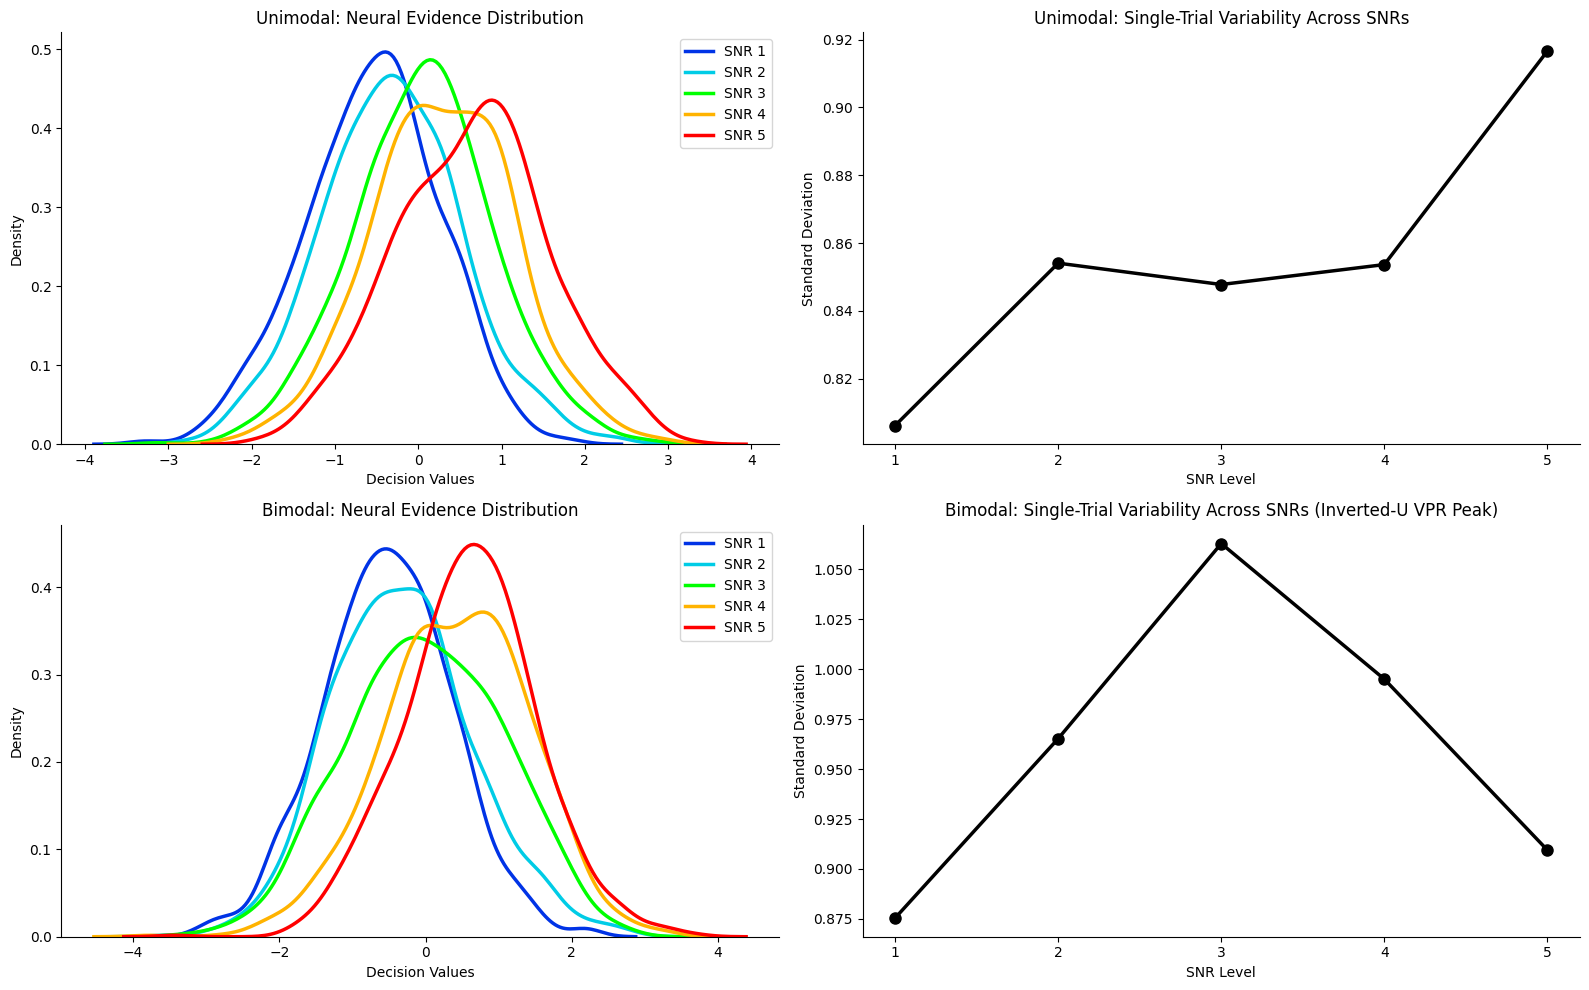

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def generate_unimodal_data_realistic(x_vec, mu_min, mu_max, sigma_low, sigma_high, n_trials_per_snr=500):
    """
    Generates Unimodal data where mean shifts linearly from mu_min to mu_max,
    and standard deviation interpolates linearly from sigma_low to sigma_high.
    """
    data, snr_list = [], []
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        mu = mu_min + x_vec[i] * (mu_max - mu_min)
        # Interpolate variance linearly across SNRs to match unimodal physics
        sig = sigma_low + x_vec[i] * (sigma_high - sigma_low)
        samples = np.random.normal(loc=mu, scale=sig, size=n_trials_per_snr)
        data.extend(samples)
        snr_list.extend([snr] * n_trials_per_snr)
    return np.array(data), np.array(snr_list)

def generate_bimodal_data_realistic(p_high_vec, mu_h_vec, mu_min, sigma_low, sigma_high, n_trials_per_snr=500):
    """
    Generates Bimodal data. Mixture proportion p_high creates maximum variance at intermediate SNRs 
    (producing the characteristic inverted-U Variability Peak Ratio curve).
    """
    data, snr_list = [], []
    for i, snr in enumerate([1, 2, 3, 4, 5]):
        p_high = p_high_vec[i]
        n_high = np.random.binomial(n_trials_per_snr, p_high)
        n_low = n_trials_per_snr - n_high
        
        low_samples = np.random.normal(loc=mu_min, scale=sigma_low, size=n_low)
        high_samples = np.random.normal(loc=mu_h_vec[i], scale=sigma_high, size=n_high)
        
        samples = np.concatenate([low_samples, high_samples])
        np.random.shuffle(samples)
        
        data.extend(samples)
        snr_list.extend([snr] * n_trials_per_snr)
    return np.array(data), np.array(snr_list)


def plot_realistic_synthetic_diagnostics(sim_output_dir, emp_ranges):
    SNR_COLORS = [[0, 0.2, 0.9], [0, 0.8, 0.9], [0, 1, 0], [1, 0.7, 0], [1, 0, 0]]
    snr_range = np.array([1, 2, 3, 4, 5])
    
    # 1. Representative mean values from subject empirical ranges
    mu_min = np.mean(emp_ranges['m_min'])
    mu_max = np.mean(emp_ranges['m_max'])
    s_l = np.mean(emp_ranges['s_l'])
    s_h = np.mean(emp_ranges['s_h'])
    
    # Sigmoidal transition vectors across 5 SNRs (Low -> Mid -> High)
    x_unimodal = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
    p_high_bimodal = np.array([0.05, 0.20, 0.50, 0.80, 0.95]) # Peak mixture variance around SNR 3
    mu_h_bimodal = np.array([mu_max]*5)                       # Fixed high state level
    
    # 2. Generate smooth diagnostic synthetic datasets (using N=1000 trials to reduce sampling noise)
    d_uni, snr_uni = generate_unimodal_data_realistic(
        x_unimodal, mu_min, mu_max, s_l, s_h, n_trials_per_snr=1000
    )
    d_bi, snr_bi = generate_bimodal_data_realistic(
        p_high_bimodal, mu_h_bimodal, mu_min, s_l, s_h, n_trials_per_snr=1000
    )
    
    # 3. Diagnostic Plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # --- Row 1: Unimodal ---
    for i, sn in enumerate(snr_range):
        subset = d_uni[snr_uni == sn]
        sns.kdeplot(subset, ax=axes[0, 0], color=SNR_COLORS[i], label=f'SNR {sn}', lw=2.5)
    axes[0, 0].set_title("Unimodal: Neural Evidence Distribution")
    axes[0, 0].set_xlabel("Decision Values")
    axes[0, 0].set_ylabel("Density")
    axes[0, 0].legend(loc='upper right')
    
    stds_uni = [np.std(d_uni[snr_uni == sn]) for sn in snr_range]
    axes[0, 1].plot(snr_range, stds_uni, 'ko-', lw=2.5, markersize=8)
    axes[0, 1].set_title("Unimodal: Single-Trial Variability Across SNRs")
    axes[0, 1].set_xlabel("SNR Level")
    axes[0, 1].set_ylabel("Standard Deviation")
    axes[0, 1].set_xticks(snr_range)
    
    # --- Row 2: Bimodal ---
    for i, sn in enumerate(snr_range):
        subset = d_bi[snr_bi == sn]
        sns.kdeplot(subset, ax=axes[1, 0], color=SNR_COLORS[i], label=f'SNR {sn}', lw=2.5)
    axes[1, 0].set_title("Bimodal: Neural Evidence Distribution")
    axes[1, 0].set_xlabel("Decision Values")
    axes[1, 0].set_ylabel("Density")
    axes[1, 0].legend(loc='upper right')
    
    stds_bi = [np.std(d_bi[snr_bi == sn]) for sn in snr_range]
    axes[1, 1].plot(snr_range, stds_bi, 'ko-', lw=2.5, markersize=8)
    axes[1, 1].set_title("Bimodal: Single-Trial Variability Across SNRs (Inverted-U VPR Peak)")
    axes[1, 1].set_xlabel("SNR Level")
    axes[1, 1].set_ylabel("Standard Deviation")
    axes[1, 1].set_xticks(snr_range)
    
    sns.despine()
    plt.tight_layout()
    plt.savefig(os.path.join(sim_output_dir, 'realistic_synthetic_diagnostics.png'), dpi=300)
    plt.show()

# Run
plot_realistic_synthetic_diagnostics(sim_output_dir, emp_ranges)